# Customer Retention Intelligence — Iteration 2: Explainability

This notebook adds the minimum explainability layer needed for the final assistant.

By the end of this notebook, you will be able to:

- calculate churn probability for a customer
- explain why one customer is likely to churn
- see which factors generally drive churn across the dataset
- prepare the explanation outputs for the later chat interface

This notebook expects:

- dataset: `../data/Customer_Churn_Dataset.xlsx`
- trained model: `../models/baseline_retention_model.joblib`


## 0. Install SHAP if needed

If the import below fails, run this once in your terminal:

```bash
pip install shap
```

Also add `shap` to your `requirements.txt`.


In [4]:
%pip install shap openpyxl joblib matplotlib pandas numpy scikit-learn

  Using cached shap-0.52.0-cp312-abi3-macosx_11_0_arm64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
INFO: pip is looking at multiple versions of contourpy to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
Using cached shap-0.52.0-cp312-abi3-macosx_11_0_arm64.whl (490 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 6.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 6.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 2.0 MB/s eta 0:00:0000:0100:01m
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.2
    Uninstalling numpy-1.26.2:
      Successfully uninstalled numpy-1.26.2
  Attempting uninstall: llvmlite
    Found 

In [5]:
df = pd.read_excel(
    "../data/Customer_Churn_Dataset.xlsx",
    sheet_name="01 Churn-Dataset"
)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (7043, 23)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,0,0,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,0,0,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0,Yes


In [6]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt


## 1. Load the trained model

In [7]:
model = joblib.load("../models/baseline_retention_model.joblib")

print("Model loaded successfully.")


Model loaded successfully.


## 2. Load the dataset

In [8]:
df = pd.read_excel(
    "../data/Customer_Churn_Dataset.xlsx",
    sheet_name="01 Churn-Dataset"
)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (7043, 23)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,0,0,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,0,0,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0,Yes


## 3. Prepare the data exactly like Iteration 1

In [9]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

customer_ids = df["customerID"].copy()

df_model = df.drop(columns=["customerID"]).copy()

df_model["Churn"] = df_model["Churn"].replace({
    "No": 0,
    "Yes": 1
})

X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())


Features shape: (7043, 21)
Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


/var/folders/w_/43h9l4cs4_72fhxz6gkrg6sr0000gn/T/ipykernel_65501/2177416481.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model["Churn"] = df_model["Churn"].replace({


## 4. Extract the preprocessing step and classifier

The saved model is a scikit-learn `Pipeline`.

We separate:
- the preprocessing logic
- the Logistic Regression classifier


In [10]:
preprocessor = model.named_steps["preprocessor"]
classifier = model.named_steps["classifier"]

print("Preprocessor:", type(preprocessor).__name__)
print("Classifier:", type(classifier).__name__)


Preprocessor: ColumnTransformer
Classifier: LogisticRegression


## 5. Transform the customer features

In [11]:
X_processed = preprocessor.transform(X)

feature_names = preprocessor.get_feature_names_out()

print("Processed shape:", X_processed.shape)
print("Number of processed features:", len(feature_names))
print()
print("First 20 processed feature names:")
print(feature_names[:20])


Processed shape: (7043, 47)
Number of processed features: 47

First 20 processed feature names:
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'num__numAdminTickets' 'num__numTechTickets'
 'cat__gender_Female' 'cat__gender_Male' 'cat__Partner_No'
 'cat__Partner_Yes' 'cat__Dependents_No' 'cat__Dependents_Yes'
 'cat__PhoneService_No' 'cat__PhoneService_Yes' 'cat__MultipleLines_No'
 'cat__MultipleLines_No phone service' 'cat__MultipleLines_Yes'
 'cat__InternetService_DSL' 'cat__InternetService_Fiber optic'
 'cat__InternetService_No']


## 6. Create the SHAP explainer

Because the baseline model is Logistic Regression, we use `LinearExplainer`.


In [12]:
explainer = shap.LinearExplainer(
    classifier,
    X_processed
)

shap_values = explainer(X_processed)

print("SHAP values created successfully.")
print("SHAP shape:", shap_values.values.shape)


Background dataset has 7043 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=7043 when initializing the masker.


SHAP values created successfully.
SHAP shape: (7043, 47)


## 7. General churn drivers

This plot helps answer:

> Why are customers generally churning?

Features near the top have the strongest overall effect on the model's predictions.


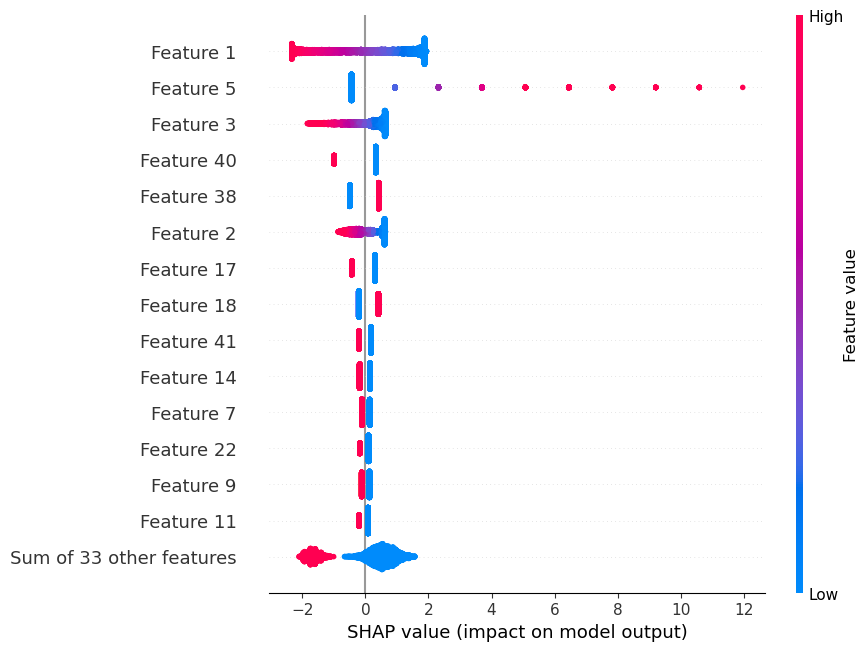

In [13]:
shap.plots.beeswarm(
    shap_values,
    max_display=15
)


## 8. Rank the overall most important churn drivers

This gives us a table we can later use in the assistant.


In [14]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

global_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
}).sort_values(
    by="mean_abs_shap",
    ascending=False
).reset_index(drop=True)

global_importance.head(20)


,feature,mean_abs_shap
0,num__tenure,1.297604
1,num__numTechTickets,0.897985
2,num__TotalCharges,0.543018
3,cat__Contract_Two year,0.490190
4,cat__Contract_Month-to-month,0.455814
5,num__MonthlyCharges,0.399686
6,cat__InternetService_DSL,0.345803
7,cat__InternetService_Fiber optic,0.299335
8,cat__PaperlessBilling_No,0.187551
9,cat__MultipleLines_No,0.164314


## 9. Predict one customer's churn risk

Change `customer_index` to inspect a different customer.


In [15]:
customer_index = 0

customer = X.iloc[[customer_index]]
customer_id = customer_ids.iloc[customer_index]

probability = model.predict_proba(customer)[0][1]
prediction = model.predict(customer)[0]

risk_level = (
    "High" if probability >= 0.60
    else "Medium" if probability >= 0.30
    else "Low"
)

print("Customer ID:", customer_id)
print("Predicted churn:", prediction)
print("Churn probability:", round(probability, 3))
print("Risk level:", risk_level)


Customer ID: 7590-VHVEG
Predicted churn: 1
Churn probability: 0.597
Risk level: Medium


## 10. Visual explanation for one customer

This waterfall plot shows which features pushed the prediction toward churn or toward staying.


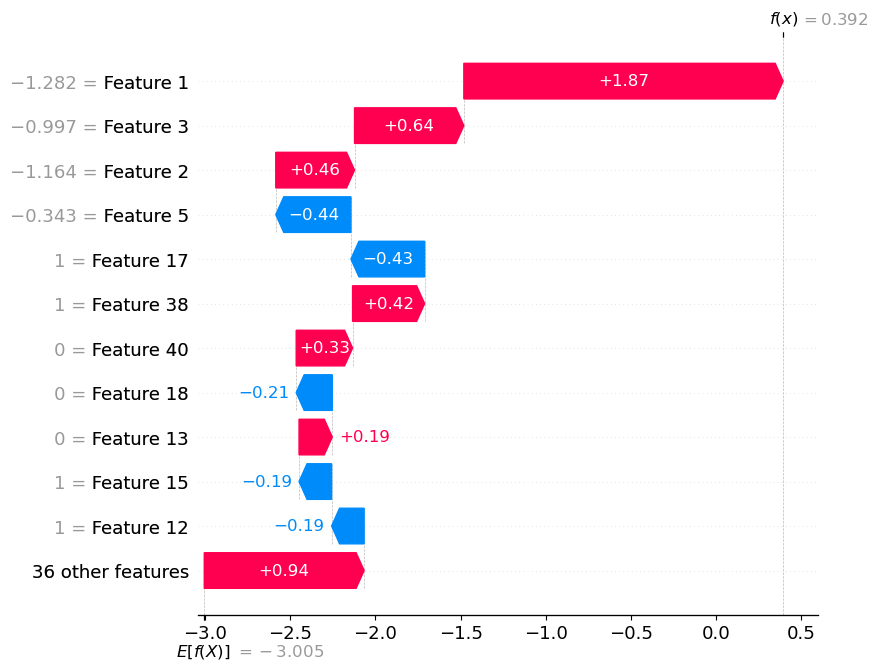

In [16]:
shap.plots.waterfall(
    shap_values[customer_index],
    max_display=12
)


## 11. Convert one customer's SHAP values into a table

This is important because the later chatbot should use structured evidence, not guess.


In [17]:
customer_shap = pd.DataFrame({
    "feature": feature_names,
    "shap_value": shap_values.values[customer_index]
})

customer_shap["absolute_impact"] = customer_shap["shap_value"].abs()

customer_shap = customer_shap.sort_values(
    by="absolute_impact",
    ascending=False
).reset_index(drop=True)

customer_shap.head(15)


,feature,shap_value,absolute_impact
0,num__tenure,1.873765,1.873765
1,num__TotalCharges,0.641394,0.641394
2,num__MonthlyCharges,0.462217,0.462217
3,num__numTechTickets,-0.441120,0.441120
4,cat__InternetService_DSL,-0.432368,0.432368
5,cat__Contract_Month-to-month,0.422744,0.422744
6,cat__Contract_Two year,0.330912,0.330912
7,cat__InternetService_Fiber optic,-0.211735,0.211735
8,cat__PhoneService_Yes,0.194980,0.194980
9,cat__PhoneService_No,-0.190945,0.190945


## 12. Separate churn-increasing and churn-reducing factors

Positive SHAP values push the model more toward churn.

Negative SHAP values push the model more toward staying.


In [18]:
risk_factors = customer_shap[
    customer_shap["shap_value"] > 0
].head(5)

protective_factors = customer_shap[
    customer_shap["shap_value"] < 0
].head(5)

print("Top factors increasing churn risk:")
display(risk_factors[["feature", "shap_value"]])

print("\nTop factors reducing churn risk:")
display(protective_factors[["feature", "shap_value"]])


Top factors increasing churn risk:


,feature,shap_value
0,num__tenure,1.873765
1,num__TotalCharges,0.641394
2,num__MonthlyCharges,0.462217
5,cat__Contract_Month-to-month,0.422744
6,cat__Contract_Two year,0.330912



Top factors reducing churn risk:


,feature,shap_value
3,num__numTechTickets,-0.441120
4,cat__InternetService_DSL,-0.432368
7,cat__InternetService_Fiber optic,-0.211735
9,cat__PhoneService_No,-0.190945
10,cat__MultipleLines_No phone service,-0.190945


## 13. Create a reusable customer explanation function

This function will later be called by the chat interface.


In [19]:
def explain_customer(customer_id, top_n=5):
    matches = customer_ids[customer_ids == customer_id].index

    if len(matches) == 0:
        return {
            "error": f"Customer {customer_id} was not found."
        }

    idx = matches[0]

    customer_row = X.iloc[[idx]]
    probability = model.predict_proba(customer_row)[0][1]
    prediction = model.predict(customer_row)[0]

    if probability >= 0.60:
        risk_level = "High"
    elif probability >= 0.30:
        risk_level = "Medium"
    else:
        risk_level = "Low"

    shap_df = pd.DataFrame({
        "feature": feature_names,
        "shap_value": shap_values.values[idx]
    })

    shap_df["absolute_impact"] = shap_df["shap_value"].abs()
    shap_df = shap_df.sort_values(
        by="absolute_impact",
        ascending=False
    )

    risk = shap_df[
        shap_df["shap_value"] > 0
    ].head(top_n)

    protective = shap_df[
        shap_df["shap_value"] < 0
    ].head(top_n)

    return {
        "customer_id": customer_id,
        "churn_probability": float(probability),
        "predicted_churn": int(prediction),
        "risk_level": risk_level,
        "risk_factors": risk[["feature", "shap_value"]].to_dict("records"),
        "protective_factors": protective[["feature", "shap_value"]].to_dict("records")
    }


## 14. Test the function

In [20]:
test_customer_id = customer_ids.iloc[0]

explanation = explain_customer(test_customer_id)

explanation


{'customer_id': '7590-VHVEG',
 'churn_probability': 0.5968838945098632,
 'predicted_churn': 1,
 'risk_level': 'Medium',
 'risk_factors': [{'feature': 'num__tenure', 'shap_value': 1.8737651256660135},
  {'feature': 'num__TotalCharges', 'shap_value': 0.6413938993228924},
  {'feature': 'num__MonthlyCharges', 'shap_value': 0.46221698877569173},
  {'feature': 'cat__Contract_Month-to-month',
   'shap_value': 0.42274416761950456},
  {'feature': 'cat__Contract_Two year', 'shap_value': 0.3309122663250063}],
 'protective_factors': [{'feature': 'num__numTechTickets',
   'shap_value': -0.44112024865691285},
  {'feature': 'cat__InternetService_DSL', 'shap_value': -0.43236844440868893},
  {'feature': 'cat__InternetService_Fiber optic',
   'shap_value': -0.21173493036830016},
  {'feature': 'cat__PhoneService_No', 'shap_value': -0.19094493350227992},
  {'feature': 'cat__MultipleLines_No phone service',
   'shap_value': -0.19094493350227992}]}

## 15. Create a reusable overall churn explanation function

This will support questions such as:

> Why are customers generally churning?


In [21]:
def explain_overall_churn(top_n=10):
    top_drivers = global_importance.head(top_n)

    return {
        "overall_churn_rate": float(y.mean()),
        "top_drivers": top_drivers.to_dict("records")
    }


## 16. Test the overall explanation

In [22]:
overall_explanation = explain_overall_churn()

overall_explanation


{'overall_churn_rate': 0.2653698707936959,
 'top_drivers': [{'feature': 'num__tenure',
   'mean_abs_shap': 1.2976036283999521},
  {'feature': 'num__numTechTickets', 'mean_abs_shap': 0.897984725981478},
  {'feature': 'num__TotalCharges', 'mean_abs_shap': 0.5430183283767861},
  {'feature': 'cat__Contract_Two year', 'mean_abs_shap': 0.4901899296561853},
  {'feature': 'cat__Contract_Month-to-month',
   'mean_abs_shap': 0.45581440135188545},
  {'feature': 'num__MonthlyCharges', 'mean_abs_shap': 0.3996861553629321},
  {'feature': 'cat__InternetService_DSL',
   'mean_abs_shap': 0.34580256675874804},
  {'feature': 'cat__InternetService_Fiber optic',
   'mean_abs_shap': 0.2993354808583487},
  {'feature': 'cat__PaperlessBilling_No',
   'mean_abs_shap': 0.18755132994401938},
  {'feature': 'cat__MultipleLines_No', 'mean_abs_shap': 0.16431424972334344}]}

# Iteration 2 complete

You now have the core evidence layer needed for your final assistant.

You can now:

- predict churn probability for a customer
- explain why that customer is at risk
- identify factors reducing that customer's risk
- identify the strongest overall churn drivers
- return explanations as structured Python dictionaries

## Next iteration

We will add only what is necessary for your final goal:

1. translate technical feature names into readable business language
2. create retention recommendations from actionable risk factors
3. build a simple natural-language question interface

After that, you will be able to ask questions like:

- "Why is this customer likely to churn?"
- "What can make this customer stay?"
- "Why are customers generally churning?"
